# Model Selection, Hyperparameter Tuning & Weight Optimization

This notebook performs:
1. **Cross-validation model selection** - Compare ensemble algorithms per dimension
2. **Hyperparameter optimization** - Grid search for best model parameters
3. **Dimension weight optimization** - Grid search for optimal ensemble weights

**Goal**: Determine optimal configuration for the wallet risk ensemble framework

## 1. Import Libraries

In [1]:
!pip install xgboost imblearn lightgbm seaborn

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    f1_score,
    accuracy_score,
    make_scorer
)
import xgboost as xgb
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import joblib
import warnings
import os
import logging

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Suppress all warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Suppress XGBoost warnings
logging.getLogger('xgboost').setLevel(logging.ERROR)

## 2. Load and Prepare Data

In [4]:
# Configuration
DATA_PATH = 'dataset_v2.csv'
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

# Feature definitions
BEHAVIORAL_FEATURES = [
    'Avg min between sent tnx',
    'Avg min between received tnx',
    'Time Diff between first and last (Mins)',
    'Sent tnx',
    'Received Tnx',
    'Number of Created Contracts',
    'total transactions (including tnx to create contract)',
    'total Ether sent',
    'total ether received'
]

ASSOCIATION_FEATURES = [
    'No. of txns from blacklisted addresses',
    'No. of txns to blacklisted addresses',
    'Total ether sent to blacklisted addresses',
    'Ratio of total sent to blacklisted addresses',
    'Total ether received from blacklisted addresses',
    'Ratio of total received from blacklisted addresses',
    'unique_wallets_interacted_with',
    #'unique_contracts_interacted_with',
    'num_blacklisted_contracts_interacted',
    'ratio_blacklisted_contract_txns'
]

CONTEXTUAL_FEATURES = [
    'avg_gas_price_gwei',
    'gas_price_std_dev',
    'high_gas_price_ratio',
    'low_gas_price_ratio',
    'gas_price_coefficient_variation',
    'total_failed_txns',
    'failed_txn_ratio',
    'max_consecutive_failures',
    'failed_contract_interaction_ratio',
    'total_erc721_transfers',
    'erc721_incoming_ratio',
    'erc721_outgoing_ratio',
    'unique_erc721_tokens',
    'external_txn_ratio',
    'erc20_txn_ratio',
    'erc721_txn_ratio',
    'erc1155_txn_ratio',
    'internal_txn_ratio'
]

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {len(df)} wallet records")
print(f"Fraud ratio: {df['FLAG'].mean():.4f}")


Dataset loaded: 28431 wallet records
Fraud ratio: 0.2515


In [5]:
# Prepare features
X_behavioral = df[BEHAVIORAL_FEATURES].copy()
X_behavioral.fillna(0, inplace=True)
X_behavioral.replace([np.inf, -np.inf], 0, inplace=True)

X_association = df[ASSOCIATION_FEATURES].copy()
X_association.fillna(0, inplace=True)
X_association.replace([np.inf, -np.inf], 0, inplace=True)

X_contextual = df[CONTEXTUAL_FEATURES].copy()
X_contextual.fillna(0, inplace=True)
X_contextual.replace([np.inf, -np.inf], 0, inplace=True)

y = df['FLAG'].copy()

# Train-test split
X_beh_train, X_beh_test, y_train, y_test = train_test_split(
    X_behavioral, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_ass_train, X_ass_test = train_test_split(
    X_association, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_ctx_train, X_ctx_test = train_test_split(
    X_contextual, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_beh_train_balanced, y_train_balanced = smote.fit_resample(X_beh_train, y_train)
X_ass_train_balanced, _ = smote.fit_resample(X_ass_train, y_train)
X_ctx_train_balanced, _ = smote.fit_resample(X_ctx_train, y_train)

print(f"\nTraining set: {len(X_beh_train_balanced)} samples (after SMOTE)")
print(f"Test set: {len(X_beh_test)} samples")


Training set: 34050 samples (after SMOTE)
Test set: 5687 samples


## 3. Phase 1: Cross-Validation Model Selection

Compare multiple ensemble algorithms for each dimension using 5-fold cross-validation

### 3.1 Behavioral Dimension - Model Comparison

In [6]:
print("="*70)
print("BEHAVIORAL DIMENSION - MODEL SELECTION (Cross-Validation)")
print("="*70)

# Scale features
behavioral_scaler = RobustScaler()
X_beh_train_scaled = behavioral_scaler.fit_transform(X_beh_train_balanced)
X_beh_test_scaled = behavioral_scaler.transform(X_beh_test)

# Define candidate models
behavioral_candidates = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Evaluate each model
behavioral_cv_results = {}

for name, model in behavioral_candidates.items():
    # Accuracy
    acc_scores = cross_val_score(model, X_beh_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='accuracy', n_jobs=-1)
    # Precision
    prec_scores = cross_val_score(model, X_beh_train_scaled, y_train_balanced, 
                                   cv=cv, scoring='precision', n_jobs=-1)
    # Recall
    rec_scores = cross_val_score(model, X_beh_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='recall', n_jobs=-1)
    # F1
    f1_scores = cross_val_score(model, X_beh_train_scaled, y_train_balanced, 
                                cv=cv, scoring='f1', n_jobs=-1)
    # ROC-AUC
    auc_scores = cross_val_score(model, X_beh_train_scaled, y_train_balanced, 
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
    
    behavioral_cv_results[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std': acc_scores.std(),
        'precision_mean': prec_scores.mean(),
        'precision_std': prec_scores.std(),
        'recall_mean': rec_scores.mean(),
        'recall_std': rec_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'roc_auc_mean': auc_scores.mean(),
        'roc_auc_std': auc_scores.std()
    }

# Convert results to DataFrame
behavioral_cv_df = pd.DataFrame(behavioral_cv_results).T

print("\n" + "="*70)
print("BEHAVIORAL DIMENSION - CROSS-VALIDATION SUMMARY")
print("="*70)
print(behavioral_cv_df[['recall_mean', 'precision_mean', 'f1_mean', 'accuracy_mean', 'roc_auc_mean']].to_string())

# Select best model based on recall (critical for fraud detection)
best_behavioral_model = behavioral_cv_df['recall_mean'].idxmax()
print(f"\nBest Model for Behavioral Dimension: {best_behavioral_model}")
print(f"Recall: {behavioral_cv_df.loc[best_behavioral_model, 'recall_mean']:.4f}")
print(f"Precision: {behavioral_cv_df.loc[best_behavioral_model, 'precision_mean']:.4f}")
print(f"F1-Score: {behavioral_cv_df.loc[best_behavioral_model, 'f1_mean']:.4f}")

BEHAVIORAL DIMENSION - MODEL SELECTION (Cross-Validation)

BEHAVIORAL DIMENSION - CROSS-VALIDATION SUMMARY
                  recall_mean  precision_mean   f1_mean  accuracy_mean  roc_auc_mean
XGBoost              0.940088        0.893981  0.916426       0.914273      0.970206
RandomForest         0.944376        0.889893  0.916305       0.913744      0.969085
GradientBoosting     0.922937        0.862301  0.891552       0.887753      0.951748
LightGBM             0.936799        0.888706  0.912091       0.909721      0.968410
AdaBoost             0.886109        0.795561  0.838370       0.829163      0.917345

Best Model for Behavioral Dimension: RandomForest
Recall: 0.9444
Precision: 0.8899
F1-Score: 0.9163


### 3.2 Association Dimension - Model Comparison

In [7]:
print("="*70)
print("ASSOCIATION DIMENSION - MODEL SELECTION (Cross-Validation)")
print("="*70)

# Scale features
association_scaler = StandardScaler()
X_ass_train_scaled = association_scaler.fit_transform(X_ass_train_balanced)
X_ass_test_scaled = association_scaler.transform(X_ass_test)

# Define candidate models
association_candidates = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

# Evaluate each model
association_cv_results = {}

for name, model in association_candidates.items():
    # Accuracy
    acc_scores = cross_val_score(model, X_ass_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='accuracy', n_jobs=-1)
    # Precision
    prec_scores = cross_val_score(model, X_ass_train_scaled, y_train_balanced, 
                                   cv=cv, scoring='precision', n_jobs=-1)
    # Recall
    rec_scores = cross_val_score(model, X_ass_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='recall', n_jobs=-1)
    # F1
    f1_scores = cross_val_score(model, X_ass_train_scaled, y_train_balanced, 
                                cv=cv, scoring='f1', n_jobs=-1)
    # ROC-AUC
    auc_scores = cross_val_score(model, X_ass_train_scaled, y_train_balanced, 
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
    
    association_cv_results[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std': acc_scores.std(),
        'precision_mean': prec_scores.mean(),
        'precision_std': prec_scores.std(),
        'recall_mean': rec_scores.mean(),
        'recall_std': rec_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'roc_auc_mean': auc_scores.mean(),
        'roc_auc_std': auc_scores.std()
    }

# Convert results to DataFrame
association_cv_df = pd.DataFrame(association_cv_results).T

print("\n" + "="*70)
print("ASSOCIATION DIMENSION - CROSS-VALIDATION SUMMARY")
print("="*70)
print(association_cv_df[['recall_mean', 'precision_mean', 'f1_mean', 'accuracy_mean', 'roc_auc_mean']].to_string())

# Select best model based on recall (critical for fraud detection)
best_association_model = association_cv_df['recall_mean'].idxmax()
print(f"\nBest Model for Association Dimension: {best_association_model}")
print(f"Recall: {association_cv_df.loc[best_association_model, 'recall_mean']:.4f}")
print(f"Precision: {association_cv_df.loc[best_association_model, 'precision_mean']:.4f}")
print(f"F1-Score: {association_cv_df.loc[best_association_model, 'f1_mean']:.4f}")

ASSOCIATION DIMENSION - MODEL SELECTION (Cross-Validation)

ASSOCIATION DIMENSION - CROSS-VALIDATION SUMMARY
                  recall_mean  precision_mean   f1_mean  accuracy_mean  roc_auc_mean
XGBoost              0.697739        0.813815  0.751219       0.768928      0.854613
RandomForest         0.566814        0.914660  0.688659       0.749750      0.854386
GradientBoosting     0.699266        0.812416  0.751486       0.768781      0.855235
LightGBM             0.708899        0.805785  0.754178       0.768928      0.856891
AdaBoost             0.708076        0.797730  0.748813       0.762996      0.848025

Best Model for Association Dimension: LightGBM
Recall: 0.7089
Precision: 0.8058
F1-Score: 0.7542


### 3.3 Contextual Dimension - Model Comparison

In [8]:
print("CONTEXTUAL DIMENSION - MODEL SELECTION (Cross-Validation)")
print("="*70)

# Scale contextual features
from sklearn.preprocessing import StandardScaler
contextual_scaler = StandardScaler()
X_ctx_train_scaled = contextual_scaler.fit_transform(X_ctx_train_balanced)
X_ctx_test_scaled = contextual_scaler.transform(X_ctx_test)

# Define candidate models
contextual_candidates = {
    'XGBoost': xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE)
}

# Cross-validation
contextual_cv_results = {}

for name, model in contextual_candidates.items():
    print(f"\nEvaluating {name}...")
    
    # Cross-validation scores
    acc_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                cv=cv, scoring='f1', n_jobs=-1)
    prec_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                   cv=cv, scoring='precision', n_jobs=-1)
    rec_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                 cv=cv, scoring='recall', n_jobs=-1)
    auc_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
    
    contextual_cv_results[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std': acc_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'precision_mean': prec_scores.mean(),
        'precision_std': prec_scores.std(),
        'recall_mean': rec_scores.mean(),
        'recall_std': rec_scores.std(),
        'roc_auc_mean': auc_scores.mean(),
        'roc_auc_std': auc_scores.std()
    }
    
    print(f"  Accuracy:  {acc_scores.mean():.4f} (+/- {acc_scores.std():.4f})")
    print(f"  F1-Score:  {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
    print(f"  Recall:    {rec_scores.mean():.4f} (+/- {rec_scores.std():.4f})")
    print(f"  Precision: {prec_scores.mean():.4f} (+/- {prec_scores.std():.4f})")
    print(f"  ROC-AUC:   {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")

# Convert to DataFrame and select best
contextual_cv_df = pd.DataFrame(contextual_cv_results).T
best_contextual_model = contextual_cv_df['recall_mean'].idxmax()

print("\n" + "="*70)
print("CONTEXTUAL DIMENSION - CROSS-VALIDATION SUMMARY")
print("="*70)
print(contextual_cv_df[['accuracy_mean', 'f1_mean', 'recall_mean', 'precision_mean', 'roc_auc_mean']].to_string())
print(f"\nBest Model: {best_contextual_model}")
print(f"Recall: {contextual_cv_df.loc[best_contextual_model, 'recall_mean']:.4f}")
print(f"Precision: {contextual_cv_df.loc[best_contextual_model, 'precision_mean']:.4f}")
print(f"F1-Score: {contextual_cv_df.loc[best_contextual_model, 'f1_mean']:.4f}")

CONTEXTUAL DIMENSION - MODEL SELECTION (Cross-Validation)

Evaluating XGBoost...
  Accuracy:  0.8381 (+/- 0.0056)
  F1-Score:  0.8416 (+/- 0.0058)
  Recall:    0.8603 (+/- 0.0075)
  Precision: 0.8237 (+/- 0.0049)
  ROC-AUC:   0.9152 (+/- 0.0047)

Evaluating RandomForest...
  Accuracy:  0.8632 (+/- 0.0046)
  F1-Score:  0.8660 (+/- 0.0048)
  Recall:    0.8840 (+/- 0.0082)
  Precision: 0.8487 (+/- 0.0038)
  ROC-AUC:   0.9362 (+/- 0.0037)

Evaluating GradientBoosting...
  Accuracy:  0.7781 (+/- 0.0055)
  F1-Score:  0.7871 (+/- 0.0055)
  Recall:    0.8201 (+/- 0.0070)
  Precision: 0.7566 (+/- 0.0048)
  ROC-AUC:   0.8622 (+/- 0.0058)

Evaluating LightGBM...
  Accuracy:  0.8275 (+/- 0.0067)
  F1-Score:  0.8328 (+/- 0.0066)
  Recall:    0.8591 (+/- 0.0075)
  Precision: 0.8081 (+/- 0.0064)
  ROC-AUC:   0.9078 (+/- 0.0042)

Evaluating AdaBoost...
  Accuracy:  0.7311 (+/- 0.0076)
  F1-Score:  0.7332 (+/- 0.0094)
  Recall:    0.7391 (+/- 0.0165)
  Precision: 0.7276 (+/- 0.0071)
  ROC-AUC:   0.7968

### 3.4 Visualize Model Comparison

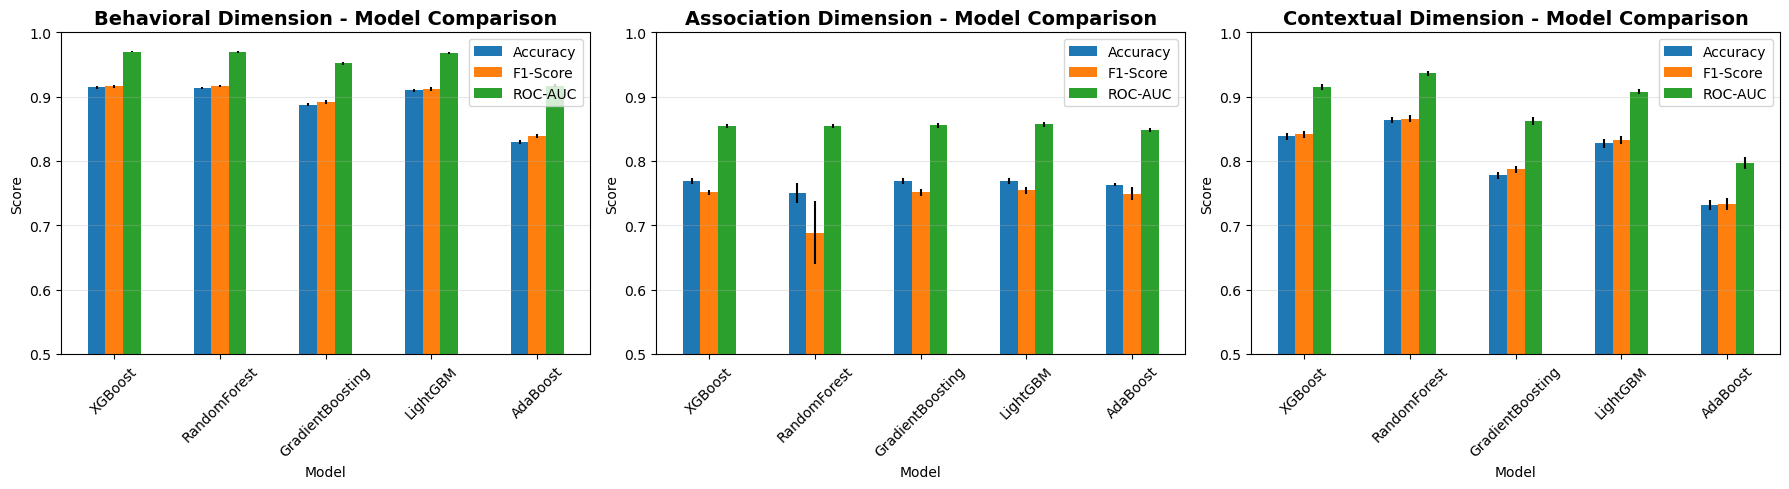

In [9]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Behavioral
behavioral_cv_df[['accuracy_mean', 'f1_mean', 'roc_auc_mean']].plot(
    kind='bar', ax=axes[0], yerr=behavioral_cv_df[['accuracy_std', 'f1_std', 'roc_auc_std']].values.T
)
axes[0].set_title('Behavioral Dimension - Model Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Association
association_cv_df[['accuracy_mean', 'f1_mean', 'roc_auc_mean']].plot(
    kind='bar', ax=axes[1], yerr=association_cv_df[['accuracy_std', 'f1_std', 'roc_auc_std']].values.T
)
axes[1].set_title('Association Dimension - Model Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Contextual
contextual_cv_df[['accuracy_mean', 'f1_mean', 'roc_auc_mean']].plot(
    kind='bar', ax=axes[2], yerr=contextual_cv_df[['accuracy_std', 'f1_std', 'roc_auc_std']].values.T
)
axes[2].set_title('Contextual Dimension - Model Comparison', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_xlabel('Model')
axes[2].set_ylim(0.5, 1.0)
axes[2].legend(['Accuracy', 'F1-Score', 'ROC-AUC'])
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Phase 2: Hyperparameter Optimization

Use GridSearchCV to find optimal hyperparameters for the best models

### 4.1 Behavioral Dimension - Hyperparameter Tuning

In [10]:
print("="*70)
print(f"HYPERPARAMETER TUNING: {best_behavioral_model} (Behavioral Dimension)")
print("="*70)

# Define hyperparameter grids for each model type
param_grids = {
    'XGBoost': {
        'n_estimators': [100, 150, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    },
    'RandomForest': {
        'n_estimators': [100, 150, 200],
        'max_depth': [8, 10, 12, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', None]
    },
    'GradientBoosting': {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9]
    },
    'LightGBM': {
        'n_estimators': [100, 150, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 70]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 150, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
    }
}

# Get the appropriate model and param grid
behavioral_model = behavioral_candidates[best_behavioral_model]
behavioral_param_grid = param_grids[best_behavioral_model]

print(f"\nSearching {len(list(product(*behavioral_param_grid.values())))} parameter combinations...")

# Grid search with multiple scoring metrics
grid_search_behavioral = GridSearchCV(
    estimator=behavioral_model,
    param_grid=behavioral_param_grid,
    scoring={'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='recall',  # Refit using recall as primary metric (critical for fraud detection)
    cv=cv,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

grid_search_behavioral.fit(X_beh_train_scaled, y_train_balanced)

print("\n" + "="*70)
print("GRID SEARCH RESULTS - BEHAVIORAL DIMENSION")
print("="*70)
print(f"Best Parameters: {grid_search_behavioral.best_params_}")
print(f"Best CV Scores:")
print(f"  Recall:     {grid_search_behavioral.best_score_:.4f}")

# Get other metrics for best estimator
cv_results_df = pd.DataFrame(grid_search_behavioral.cv_results_)
best_idx = grid_search_behavioral.best_index_
print(f"  Precision:  {cv_results_df.loc[best_idx, 'mean_test_precision']:.4f}")
print(f"  F1-Score:   {cv_results_df.loc[best_idx, 'mean_test_f1']:.4f}")
print(f"  Accuracy:   {cv_results_df.loc[best_idx, 'mean_test_accuracy']:.4f}")
print(f"  ROC-AUC:    {cv_results_df.loc[best_idx, 'mean_test_roc_auc']:.4f}")

# Save best model
best_behavioral_classifier = grid_search_behavioral.best_estimator_

HYPERPARAMETER TUNING: RandomForest (Behavioral Dimension)

Searching 432 parameter combinations...

GRID SEARCH RESULTS - BEHAVIORAL DIMENSION
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Scores:
  Recall:     0.9444
  Precision:  0.8899
  F1-Score:   0.9163
  Accuracy:   0.9137
  ROC-AUC:    0.9691


**Note:** Phase 1 uses default parameters for fair comparison. The winning model will be optimized in Phase 2.

### 4.2 Association Dimension - Hyperparameter Tuning

In [11]:
print("="*70)
print(f"HYPERPARAMETER TUNING: {best_association_model} (Association Dimension)")
print("="*70)

# Get the appropriate model and param grid
association_model = association_candidates[best_association_model]
association_param_grid = param_grids[best_association_model]

print(f"\nSearching {len(list(product(*association_param_grid.values())))} parameter combinations...")

# Grid search with multiple scoring metrics
grid_search_association = GridSearchCV(
    estimator=association_model,
    param_grid=association_param_grid,
    scoring={'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='recall',  # Refit using recall as primary metric (critical for fraud detection)
    cv=cv,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

grid_search_association.fit(X_ass_train_scaled, y_train_balanced)

print("\n" + "="*70)
print("GRID SEARCH RESULTS - ASSOCIATION DIMENSION")
print("="*70)
print(f"Best Parameters: {grid_search_association.best_params_}")
print(f"Best CV Scores:")
print(f"  Recall:     {grid_search_association.best_score_:.4f}")

# Get other metrics for best estimator
cv_results_df = pd.DataFrame(grid_search_association.cv_results_)
best_idx = grid_search_association.best_index_
print(f"  Precision:  {cv_results_df.loc[best_idx, 'mean_test_precision']:.4f}")
print(f"  F1-Score:   {cv_results_df.loc[best_idx, 'mean_test_f1']:.4f}")
print(f"  Accuracy:   {cv_results_df.loc[best_idx, 'mean_test_accuracy']:.4f}")
print(f"  ROC-AUC:    {cv_results_df.loc[best_idx, 'mean_test_roc_auc']:.4f}")

# Save best model
best_association_classifier = grid_search_association.best_estimator_

HYPERPARAMETER TUNING: LightGBM (Association Dimension)

Searching 81 parameter combinations...

GRID SEARCH RESULTS - ASSOCIATION DIMENSION
Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 31}
Best CV Scores:
  Recall:     0.7401
  Precision:  0.7819
  F1-Score:   0.7604
  Accuracy:   0.7668
  ROC-AUC:    0.8508


### 4.3 Contextual Dimension - Hyperparameter Tuning

In [12]:
print("="*70)
print(f"HYPERPARAMETER TUNING: {best_contextual_model} (Contextual Dimension)")
print("="*70)

# Get the appropriate model and param grid
contextual_model = contextual_candidates[best_contextual_model]
contextual_param_grid = param_grids[best_contextual_model]

print(f"\nSearching {len(list(product(*contextual_param_grid.values())))} parameter combinations...")

# Grid search with multiple scoring metrics
grid_search_contextual = GridSearchCV(
    estimator=contextual_model,
    param_grid=contextual_param_grid,
    scoring={'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='recall',  # Refit using recall as primary metric (critical for fraud detection)
    cv=cv,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

grid_search_contextual.fit(X_ctx_train_scaled, y_train_balanced)

print("\n" + "="*70)
print("GRID SEARCH RESULTS - CONTEXTUAL DIMENSION")
print("="*70)
print(f"Best Parameters: {grid_search_contextual.best_params_}")
print(f"Best CV Scores:")
print(f"  Recall:     {grid_search_contextual.best_score_:.4f}")

# Get other metrics for best estimator
cv_results_df = pd.DataFrame(grid_search_contextual.cv_results_)
best_idx = grid_search_contextual.best_index_
print(f"  Precision:  {cv_results_df.loc[best_idx, 'mean_test_precision']:.4f}")
print(f"  F1-Score:   {cv_results_df.loc[best_idx, 'mean_test_f1']:.4f}")
print(f"  Accuracy:   {cv_results_df.loc[best_idx, 'mean_test_accuracy']:.4f}")
print(f"  ROC-AUC:    {cv_results_df.loc[best_idx, 'mean_test_roc_auc']:.4f}")

# Save best model
best_contextual_classifier = grid_search_contextual.best_estimator_

HYPERPARAMETER TUNING: RandomForest (Contextual Dimension)

Searching 432 parameter combinations...

GRID SEARCH RESULTS - CONTEXTUAL DIMENSION
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Scores:
  Recall:     0.8860
  Precision:  0.8499
  F1-Score:   0.8676
  Accuracy:   0.8648
  ROC-AUC:    0.9368


### 3.3 Contextual Dimension - Model Comparison

In [13]:
print("="*70)
print("CONTEXTUAL DIMENSION - MODEL SELECTION (Cross-Validation)")
print("="*70)

# Scale features
contextual_scaler = StandardScaler()
X_ctx_train_scaled = contextual_scaler.fit_transform(X_ctx_train_balanced)
X_ctx_test_scaled = contextual_scaler.transform(X_ctx_test)

# Define candidate models
contextual_candidates = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    )
}

# Evaluate each model
contextual_cv_results = {}

for name, model in contextual_candidates.items():
    # Accuracy
    acc_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='accuracy', n_jobs=-1)
    # Precision
    prec_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                   cv=cv, scoring='precision', n_jobs=-1)
    # Recall
    rec_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                  cv=cv, scoring='recall', n_jobs=-1)
    # F1
    f1_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                cv=cv, scoring='f1', n_jobs=-1)
    # ROC-AUC
    auc_scores = cross_val_score(model, X_ctx_train_scaled, y_train_balanced, 
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
    
    contextual_cv_results[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std': acc_scores.std(),
        'precision_mean': prec_scores.mean(),
        'precision_std': prec_scores.std(),
        'recall_mean': rec_scores.mean(),
        'recall_std': rec_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'roc_auc_mean': auc_scores.mean(),
        'roc_auc_std': auc_scores.std()
    }

# Convert results to DataFrame
contextual_cv_df = pd.DataFrame(contextual_cv_results).T

print("\n" + "="*70)
print("CONTEXTUAL DIMENSION - CROSS-VALIDATION SUMMARY")
print("="*70)
print(contextual_cv_df[['recall_mean', 'precision_mean', 'f1_mean', 'accuracy_mean', 'roc_auc_mean']].to_string())

# Select best model based on recall (critical for fraud detection)
best_contextual_model = contextual_cv_df['recall_mean'].idxmax()
print(f"\nBest Model for Contextual Dimension: {best_contextual_model}")
print(f"Recall: {contextual_cv_df.loc[best_contextual_model, 'recall_mean']:.4f}")
print(f"Precision: {contextual_cv_df.loc[best_contextual_model, 'precision_mean']:.4f}")
print(f"F1-Score: {contextual_cv_df.loc[best_contextual_model, 'f1_mean']:.4f}")

CONTEXTUAL DIMENSION - MODEL SELECTION (Cross-Validation)

CONTEXTUAL DIMENSION - CROSS-VALIDATION SUMMARY
                  recall_mean  precision_mean   f1_mean  accuracy_mean  roc_auc_mean
XGBoost              0.864023        0.832395  0.847907       0.845022      0.921406
RandomForest         0.885991        0.849671  0.867438       0.864611      0.937036
GradientBoosting     0.833598        0.775871  0.803697       0.796388      0.879341
LightGBM             0.865374        0.821234  0.842722       0.838502      0.916851
AdaBoost             0.759648        0.742847  0.751135       0.748370      0.817245

Best Model for Contextual Dimension: RandomForest
Recall: 0.8860
Precision: 0.8497
F1-Score: 0.8674


In [14]:
print("="*70)
print("HYPERPARAMETER OPTIMIZATION IMPACT")
print("="*70)

# Get optimized accuracy scores
beh_cv_results = pd.DataFrame(grid_search_behavioral.cv_results_)
ass_cv_results = pd.DataFrame(grid_search_association.cv_results_)
ctx_cv_results = pd.DataFrame(grid_search_contextual.cv_results_)
beh_best_acc = beh_cv_results.loc[grid_search_behavioral.best_index_, 'mean_test_accuracy']
ass_best_acc = ass_cv_results.loc[grid_search_association.best_index_, 'mean_test_accuracy']
ctx_best_acc = ctx_cv_results.loc[grid_search_contextual.best_index_, 'mean_test_accuracy']

# Get optimized precision scores
beh_best_prec = beh_cv_results.loc[grid_search_behavioral.best_index_, 'mean_test_precision']
ass_best_prec = ass_cv_results.loc[grid_search_association.best_index_, 'mean_test_precision']
ctx_best_prec = ctx_cv_results.loc[grid_search_contextual.best_index_, 'mean_test_precision']

# Create comparison table
optimization_impact = pd.DataFrame({
    'Dimension': ['Behavioral', 'Association', 'Contextual'],
    'Selected Model': [best_behavioral_model, best_association_model, best_contextual_model],
    'Phase 1 Recall': [
        behavioral_cv_df.loc[best_behavioral_model, 'recall_mean'],
        association_cv_df.loc[best_association_model, 'recall_mean'],
        contextual_cv_df.loc[best_contextual_model, 'recall_mean']
    ],
    'Phase 2 Recall': [
        grid_search_behavioral.best_score_,
        grid_search_association.best_score_,
        grid_search_contextual.best_score_
    ],
    'Phase 1 Precision': [
        behavioral_cv_df.loc[best_behavioral_model, 'precision_mean'],
        association_cv_df.loc[best_association_model, 'precision_mean'],
        contextual_cv_df.loc[best_contextual_model, 'precision_mean']
    ],
    'Phase 2 Precision': [
        beh_best_prec,
        ass_best_prec,
        ctx_best_prec
    ],
    'Phase 1 Acc': [
        behavioral_cv_df.loc[best_behavioral_model, 'accuracy_mean'],
        association_cv_df.loc[best_association_model, 'accuracy_mean'],
        contextual_cv_df.loc[best_contextual_model, 'accuracy_mean']
    ],
    'Phase 2 Acc': [
        beh_best_acc,
        ass_best_acc,
        ctx_best_acc
    ]
})

optimization_impact['Recall Improvement'] = (
    optimization_impact['Phase 2 Recall'] - optimization_impact['Phase 1 Recall']
)
optimization_impact['Precision Improvement'] = (
    optimization_impact['Phase 2 Precision'] - optimization_impact['Phase 1 Precision']
)
optimization_impact['Acc Improvement'] = (
    optimization_impact['Phase 2 Acc'] - optimization_impact['Phase 1 Acc']
)

print("\n" + optimization_impact.to_string(index=False))

print("\n" + "="*70)
print("Key Findings:")
print(f"  Behavioral {best_behavioral_model}:")
print(f"    - Recall improved by {optimization_impact.iloc[0]['Recall Improvement']:.4f} "
      f"({(optimization_impact.iloc[0]['Recall Improvement'] / optimization_impact.iloc[0]['Phase 1 Recall']) * 100:.2f}%)")
print(f"    - Precision improved by {optimization_impact.iloc[0]['Precision Improvement']:.4f} "
      f"({(optimization_impact.iloc[0]['Precision Improvement'] / optimization_impact.iloc[0]['Phase 1 Precision']) * 100:.2f}%)")
print(f"    - Accuracy improved by {optimization_impact.iloc[0]['Acc Improvement']:.4f} "
      f"({(optimization_impact.iloc[0]['Acc Improvement'] / optimization_impact.iloc[0]['Phase 1 Acc']) * 100:.2f}%)")
print(f"  Association {best_association_model}:")
print(f"    - Recall improved by {optimization_impact.iloc[1]['Recall Improvement']:.4f} "
      f"({(optimization_impact.iloc[1]['Recall Improvement'] / optimization_impact.iloc[1]['Phase 1 Recall']) * 100:.2f}%)")
print(f"    - Precision improved by {optimization_impact.iloc[1]['Precision Improvement']:.4f} "
      f"({(optimization_impact.iloc[1]['Precision Improvement'] / optimization_impact.iloc[1]['Phase 1 Precision']) * 100:.2f}%)")
print(f"    - Accuracy improved by {optimization_impact.iloc[1]['Acc Improvement']:.4f} "
      f"({(optimization_impact.iloc[1]['Acc Improvement'] / optimization_impact.iloc[1]['Phase 1 Acc']) * 100:.2f}%)")
print(f"  Contextual {best_contextual_model}:")
print(f"    - Recall improved by {optimization_impact.iloc[2]['Recall Improvement']:.4f} "
      f"({(optimization_impact.iloc[2]['Recall Improvement'] / optimization_impact.iloc[2]['Phase 1 Recall']) * 100:.2f}%)")
print(f"    - Precision improved by {optimization_impact.iloc[2]['Precision Improvement']:.4f} "
      f"({(optimization_impact.iloc[2]['Precision Improvement'] / optimization_impact.iloc[2]['Phase 1 Precision']) * 100:.2f}%)")
print(f"    - Accuracy improved by {optimization_impact.iloc[2]['Acc Improvement']:.4f} "
      f"({(optimization_impact.iloc[2]['Acc Improvement'] / optimization_impact.iloc[2]['Phase 1 Acc']) * 100:.2f}%)")
print("="*70)

HYPERPARAMETER OPTIMIZATION IMPACT

  Dimension Selected Model  Phase 1 Recall  Phase 2 Recall  Phase 1 Precision  Phase 2 Precision  Phase 1 Acc  Phase 2 Acc  Recall Improvement  Precision Improvement  Acc Improvement
 Behavioral   RandomForest        0.944376        0.944376           0.889893           0.889893     0.913744     0.913744            0.000000               0.000000         0.000000
Association       LightGBM        0.708899        0.740147           0.805785           0.781890     0.768928     0.766784            0.031248              -0.023895        -0.002144
 Contextual   RandomForest        0.885991        0.885991           0.849671           0.849904     0.864611     0.864758            0.000000               0.000233         0.000147

Key Findings:
  Behavioral RandomForest:
    - Recall improved by 0.0000 (0.00%)
    - Precision improved by 0.0000 (0.00%)
    - Accuracy improved by 0.0000 (0.00%)
  Association LightGBM:
    - Recall improved by 0.0312 (4.41%)
 

### 4.3 Compare Optimization Impact

## 5. Phase 3: Dimension Weight Optimization

Use grid search to find optimal weights for combining dimension scores

In [15]:
print("="*70)
print("DIMENSION WEIGHT OPTIMIZATION")
print("="*70)

# Get predictions from optimized models
behavioral_proba = best_behavioral_classifier.predict_proba(X_beh_test_scaled)[:, 1]
association_proba = best_association_classifier.predict_proba(X_ass_test_scaled)[:, 1]
contextual_proba = best_contextual_classifier.predict_proba(X_ctx_test_scaled)[:, 1]

# Define weight search space with minimum weight constraint
# Each dimension must have at least 0.05 weight (5%)
# Weights must sum to 1.0
MIN_WEIGHT = 0.05
weight_step = 0.05
weight_combinations = []

for w_beh in np.arange(MIN_WEIGHT, 1.0 - 2*MIN_WEIGHT + weight_step, weight_step):
    for w_ass in np.arange(MIN_WEIGHT, 1.0 - w_beh - MIN_WEIGHT + weight_step, weight_step):
        w_ctx = 1.0 - w_beh - w_ass
        # Ensure all weights are >= MIN_WEIGHT and sum to 1.0
        if w_ctx >= MIN_WEIGHT and abs(w_beh + w_ass + w_ctx - 1.0) < 0.01:
            weight_combinations.append((round(w_beh, 2), round(w_ass, 2), round(w_ctx, 2)))

print(f"\nTesting {len(weight_combinations)} weight combinations...")
print(f"Constraint: Each dimension weight >= {MIN_WEIGHT} (minimum 5% contribution)\n")

# Grid search over weights
weight_results = []

for w_beh, w_ass, w_ctx in weight_combinations:
    # Calculate ensemble score
    ensemble_proba = (w_beh * behavioral_proba + 
                     w_ass * association_proba + 
                     w_ctx * contextual_proba)
    ensemble_pred = (ensemble_proba >= 0.5).astype(int)
    
    # Calculate metrics
    from sklearn.metrics import recall_score, precision_score
    recall = recall_score(y_test, ensemble_pred)
    precision = precision_score(y_test, ensemble_pred)
    accuracy = accuracy_score(y_test, ensemble_pred)
    f1 = f1_score(y_test, ensemble_pred)
    roc_auc = roc_auc_score(y_test, ensemble_proba)
    
    weight_results.append({
        'behavioral_weight': w_beh,
        'association_weight': w_ass,
        'contextual_weight': w_ctx,
        'recall': recall,
        'precision': precision,
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc
    })
    
    if len(weight_results) % 50 == 0:  # Print every 50th combination
        print(f"Behavioral: {w_beh:.2f}, Association: {w_ass:.2f}, Contextual: {w_ctx:.2f} | "
              f"Recall: {recall:.4f}, Prec: {precision:.4f}, F1: {f1:.4f}, Acc: {accuracy:.4f}")

# Convert to DataFrame
weight_results_df = pd.DataFrame(weight_results)

# Find optimal weights based on F1-score (harmonic mean of precision and recall)
best_weight_idx = weight_results_df['f1_score'].idxmax()
optimal_weights = weight_results_df.iloc[best_weight_idx]

print("\n" + "="*70)
print("OPTIMAL DIMENSION WEIGHTS")
print("="*70)
print(f"Behavioral Weight: {optimal_weights['behavioral_weight']:.2f}")
print(f"Association Weight: {optimal_weights['association_weight']:.2f}")
print(f"Contextual Weight: {optimal_weights['contextual_weight']:.2f}")
print(f"Sum of Weights: {optimal_weights['behavioral_weight'] + optimal_weights['association_weight'] + optimal_weights['contextual_weight']:.2f}")
print(f"\nPerformance with Optimal Weights:")
print(f"  F1-Score:   {optimal_weights['f1_score']:.4f}  (Primary Metric)")
print(f"  Recall:     {optimal_weights['recall']:.4f}")
print(f"  Precision:  {optimal_weights['precision']:.4f}")
print(f"  Accuracy:   {optimal_weights['accuracy']:.4f}")
print(f"  ROC-AUC:    {optimal_weights['roc_auc']:.4f}")

print(f"\n All dimensions contribute meaningfully (min weight: {MIN_WEIGHT})")

DIMENSION WEIGHT OPTIMIZATION

Testing 154 weight combinations...
Constraint: Each dimension weight >= 0.05 (minimum 5% contribution)

Behavioral: 0.20, Association: 0.10, Contextual: 0.70 | Recall: 0.7734, Prec: 0.7131, F1: 0.7420, Acc: 0.8648
Behavioral: 0.40, Association: 0.10, Contextual: 0.50 | Recall: 0.8308, Prec: 0.8244, F1: 0.8276, Acc: 0.9130
Behavioral: 0.75, Association: 0.10, Contextual: 0.15 | Recall: 0.8790, Prec: 0.7837, F1: 0.8286, Acc: 0.9086

OPTIMAL DIMENSION WEIGHTS
Behavioral Weight: 0.25
Association Weight: 0.60
Contextual Weight: 0.15
Sum of Weights: 1.00

Performance with Optimal Weights:
  F1-Score:   0.8870  (Primary Metric)
  Recall:     0.9000
  Precision:  0.8743
  Accuracy:   0.9423
  ROC-AUC:    0.9790

 All dimensions contribute meaningfully (min weight: 0.05)


### 5.1 Visualize Weight Impact

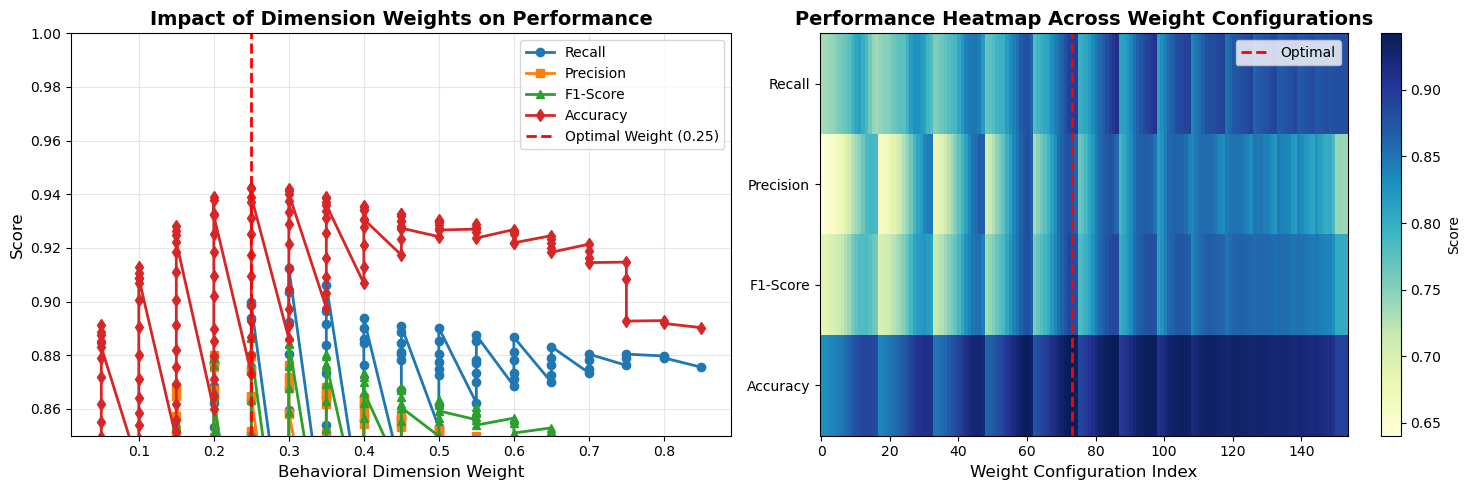

In [16]:
# Plot weight impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot - now including recall and precision
axes[0].plot(weight_results_df['behavioral_weight'], weight_results_df['recall'], 
             marker='o', label='Recall', linewidth=2)
axes[0].plot(weight_results_df['behavioral_weight'], weight_results_df['precision'], 
             marker='s', label='Precision', linewidth=2)
axes[0].plot(weight_results_df['behavioral_weight'], weight_results_df['f1_score'], 
             marker='^', label='F1-Score', linewidth=2)
axes[0].plot(weight_results_df['behavioral_weight'], weight_results_df['accuracy'], 
             marker='d', label='Accuracy', linewidth=2)
axes[0].axvline(optimal_weights['behavioral_weight'], color='red', linestyle='--', 
                label=f'Optimal Weight ({optimal_weights["behavioral_weight"]:.2f})', linewidth=2)
axes[0].set_xlabel('Behavioral Dimension Weight', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Impact of Dimension Weights on Performance', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.85, 1.0)

# Heatmap-style visualization - now including recall and precision
metrics_matrix = weight_results_df[['recall', 'precision', 'f1_score', 'accuracy']].values
im = axes[1].imshow(metrics_matrix.T, aspect='auto', cmap='YlGnBu', interpolation='nearest')
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(['Recall', 'Precision', 'F1-Score', 'Accuracy'])
axes[1].set_xlabel('Weight Configuration Index', fontsize=12)
axes[1].set_title('Performance Heatmap Across Weight Configurations', fontsize=14, fontweight='bold')
axes[1].axvline(best_weight_idx, color='red', linestyle='--', linewidth=2, label='Optimal')
plt.colorbar(im, ax=axes[1], label='Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Phase 4: Threshold Optimization

Find the optimal classification threshold to maximize recall while maintaining good overall performance

In [17]:
print("="*70)
print("THRESHOLD OPTIMIZATION")
print("="*70)

# Calculate ensemble probabilities with optimal weights
ensemble_proba_optimal = (
    optimal_weights['behavioral_weight'] * behavioral_proba + 
    optimal_weights['association_weight'] * association_proba
)

# Define threshold search space
threshold_grid = np.arange(0.1, 0.95, 0.05)  # Test thresholds from 0.1 to 0.9 in 0.05 steps

print(f"\nTesting {len(threshold_grid)} threshold values...\n")

# Grid search over thresholds
threshold_results = []

for threshold in threshold_grid:
    # Apply threshold
    ensemble_pred = (ensemble_proba_optimal >= threshold).astype(int)
    
    # Calculate metrics
    from sklearn.metrics import recall_score, precision_score
    recall = recall_score(y_test, ensemble_pred)
    precision = precision_score(y_test, ensemble_pred)
    accuracy = accuracy_score(y_test, ensemble_pred)
    f1 = f1_score(y_test, ensemble_pred)
    roc_auc = roc_auc_score(y_test, ensemble_proba_optimal)
    
    threshold_results.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc
    })
    
    print(f"Threshold: {threshold:.2f} | Recall: {recall:.4f}, Prec: {precision:.4f}, "
          f"F1: {f1:.4f}, Acc: {accuracy:.4f}")

# Convert to DataFrame
threshold_results_df = pd.DataFrame(threshold_results)

# Find optimal threshold based on F1-score (harmonic mean of precision and recall)
best_threshold_idx = threshold_results_df['f1_score'].idxmax()
optimal_threshold = threshold_results_df.iloc[best_threshold_idx]

print("\n" + "="*70)
print("OPTIMAL CLASSIFICATION THRESHOLD")
print("="*70)
print(f"Optimal Threshold: {optimal_threshold['threshold']:.2f}")
print(f"\nPerformance with Optimal Threshold:")
print(f"  F1-Score:   {optimal_threshold['f1_score']:.4f}  (Primary Metric)")
print(f"  Recall:     {optimal_threshold['recall']:.4f}")
print(f"  Precision:  {optimal_threshold['precision']:.4f}")
print(f"  Accuracy:   {optimal_threshold['accuracy']:.4f}")
print(f"  ROC-AUC:    {optimal_threshold['roc_auc']:.4f}")

# Compare with default 0.5 threshold
default_threshold_row = threshold_results_df[threshold_results_df['threshold'] == 0.5]
if not default_threshold_row.empty:
    default_f1 = default_threshold_row.iloc[0]['f1_score']
    default_recall = default_threshold_row.iloc[0]['recall']
    default_precision = default_threshold_row.iloc[0]['precision']
    default_acc = default_threshold_row.iloc[0]['accuracy']
    
    print(f"\nComparison with Default Threshold (0.5):")
    print(f"  F1-Score improvement:   {optimal_threshold['f1_score'] - default_f1:+.4f} "
          f"({((optimal_threshold['f1_score'] / default_f1) - 1) * 100:+.2f}%)")
    print(f"  Recall change:          {optimal_threshold['recall'] - default_recall:+.4f} "
          f"({((optimal_threshold['recall'] / default_recall) - 1) * 100:+.2f}%)")
    print(f"  Precision change:       {optimal_threshold['precision'] - default_precision:+.4f} "
          f"({((optimal_threshold['precision'] / default_precision) - 1) * 100:+.2f}%)")
    print(f"  Accuracy change:        {optimal_threshold['accuracy'] - default_acc:+.4f} "
          f"({((optimal_threshold['accuracy'] / default_acc) - 1) * 100:+.2f}%)")

THRESHOLD OPTIMIZATION

Testing 17 threshold values...

Threshold: 0.10 | Recall: 1.0000, Prec: 0.2515, F1: 0.4019, Acc: 0.2515
Threshold: 0.15 | Recall: 0.9993, Prec: 0.2716, F1: 0.4271, Acc: 0.3258
Threshold: 0.20 | Recall: 0.9986, Prec: 0.2887, F1: 0.4479, Acc: 0.3810
Threshold: 0.25 | Recall: 0.9902, Prec: 0.4060, F1: 0.5758, Acc: 0.6332
Threshold: 0.30 | Recall: 0.9797, Prec: 0.5130, F1: 0.6734, Acc: 0.7610
Threshold: 0.35 | Recall: 0.9580, Prec: 0.6965, F1: 0.8066, Acc: 0.8845
Threshold: 0.40 | Recall: 0.9224, Prec: 0.7989, F1: 0.8562, Acc: 0.9221
Threshold: 0.45 | Recall: 0.8490, Prec: 0.8772, F1: 0.8628, Acc: 0.9321
Threshold: 0.50 | Recall: 0.6986, Prec: 0.9416, F1: 0.8021, Acc: 0.9133
Threshold: 0.55 | Recall: 0.5273, Prec: 0.9831, F1: 0.6864, Acc: 0.8788
Threshold: 0.60 | Recall: 0.4014, Prec: 0.9897, F1: 0.5711, Acc: 0.8484
Threshold: 0.65 | Recall: 0.2895, Prec: 0.9904, F1: 0.4481, Acc: 0.8206
Threshold: 0.70 | Recall: 0.2238, Prec: 1.0000, F1: 0.3657, Acc: 0.8048
Threshol

### 6.1 Visualize Threshold Impact

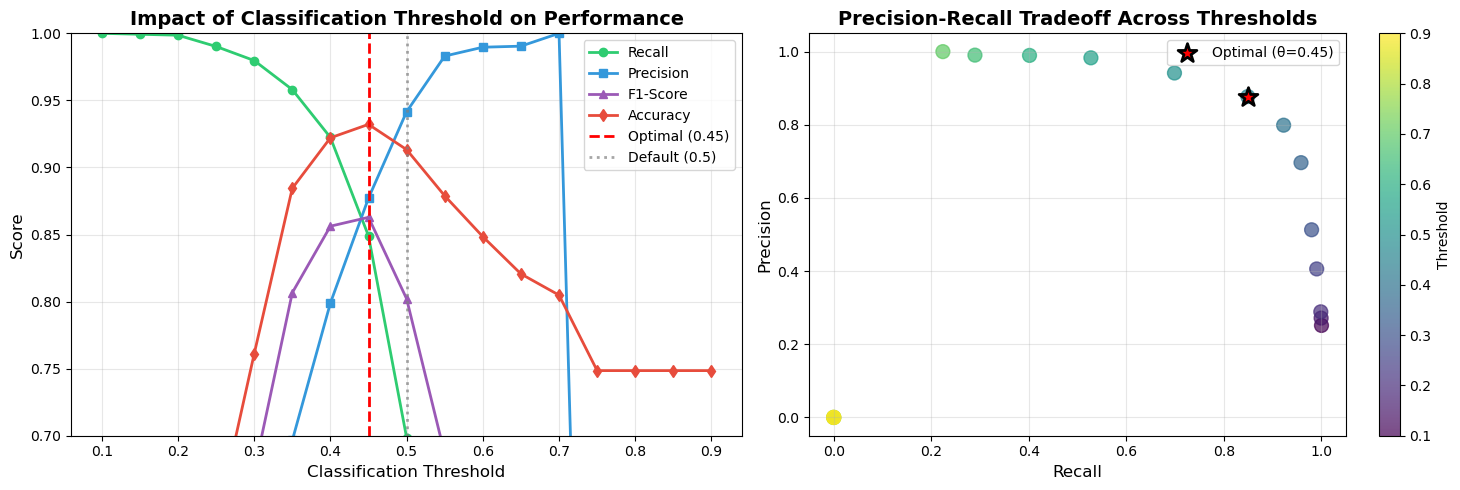

In [18]:
# Plot threshold impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot showing metric changes across thresholds
axes[0].plot(threshold_results_df['threshold'], threshold_results_df['recall'], 
             marker='o', label='Recall', linewidth=2, color='#2ecc71')
axes[0].plot(threshold_results_df['threshold'], threshold_results_df['precision'], 
             marker='s', label='Precision', linewidth=2, color='#3498db')
axes[0].plot(threshold_results_df['threshold'], threshold_results_df['f1_score'], 
             marker='^', label='F1-Score', linewidth=2, color='#9b59b6')
axes[0].plot(threshold_results_df['threshold'], threshold_results_df['accuracy'], 
             marker='d', label='Accuracy', linewidth=2, color='#e74c3c')
axes[0].axvline(optimal_threshold['threshold'], color='red', linestyle='--', 
                label=f'Optimal ({optimal_threshold["threshold"]:.2f})', linewidth=2)
axes[0].axvline(0.5, color='gray', linestyle=':', 
                label='Default (0.5)', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Classification Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Impact of Classification Threshold on Performance', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.7, 1.0)

# Precision-Recall tradeoff
axes[1].scatter(threshold_results_df['recall'], threshold_results_df['precision'], 
                c=threshold_results_df['threshold'], cmap='viridis', s=100, alpha=0.7)
axes[1].scatter(optimal_threshold['recall'], optimal_threshold['precision'], 
                color='red', s=200, marker='*', edgecolors='black', linewidths=2,
                label=f'Optimal (θ={optimal_threshold["threshold"]:.2f})', zorder=5)
if not default_threshold_row.empty:
    axes[1].scatter(default_recall, default_precision, 
                    color='gray', s=200, marker='X', edgecolors='black', linewidths=2,
                    label='Default (θ=0.5)', zorder=5)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Tradeoff Across Thresholds', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1], label='Threshold')

plt.tight_layout()
plt.show()

## 7. Final Evaluation with Optimized Configuration

In [19]:
print("="*70)
print("FINAL ENSEMBLE EVALUATION (OPTIMIZED CONFIGURATION)")
print("="*70)

# Calculate final ensemble predictions with optimized threshold
final_ensemble_proba = ensemble_proba_optimal
final_ensemble_pred = (final_ensemble_proba >= optimal_threshold['threshold']).astype(int)

# Metrics
print("\nConfiguration Summary:")
print(f"  Behavioral Model: {best_behavioral_model}")
print(f"    Parameters: {grid_search_behavioral.best_params_}")
print(f"    Weight: {optimal_weights['behavioral_weight']:.2f}")
print(f"\n  Association Model: {best_association_model}")
print(f"    Parameters: {grid_search_association.best_params_}")
print(f"    Weight: {optimal_weights['association_weight']:.2f}")
print(f"\n  Classification Threshold: {optimal_threshold['threshold']:.2f}")

print("\n" + "="*70)
print("Classification Report:")
print(classification_report(y_test, final_ensemble_pred, target_names=['Legitimate', 'Fraud']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, final_ensemble_pred)
print(cm)

final_recall = recall_score(y_test, final_ensemble_pred)
final_precision = precision_score(y_test, final_ensemble_pred)
final_acc = accuracy_score(y_test, final_ensemble_pred)
final_f1 = f1_score(y_test, final_ensemble_pred)
final_auc = roc_auc_score(y_test, final_ensemble_proba)

print(f"\nFinal Performance:")
print(f"  Recall:     {final_recall:.4f}")
print(f"  Precision:  {final_precision:.4f}")
print(f"  F1-Score:   {final_f1:.4f}")
print(f"  Accuracy:   {final_acc:.4f}")
print(f"  ROC-AUC:    {final_auc:.4f}")

FINAL ENSEMBLE EVALUATION (OPTIMIZED CONFIGURATION)

Configuration Summary:
  Behavioral Model: RandomForest
    Parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    Weight: 0.25

  Association Model: LightGBM
    Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 31}
    Weight: 0.60

  Classification Threshold: 0.45

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.95      4257
       Fraud       0.88      0.85      0.86      1430

    accuracy                           0.93      5687
   macro avg       0.91      0.90      0.91      5687
weighted avg       0.93      0.93      0.93      5687

Confusion Matrix:
[[4087  170]
 [ 216 1214]]

Final Performance:
  Recall:     0.8490
  Precision:  0.8772
  F1-Score:   0.8628
  Accuracy:   0.9321
  ROC-AUC:    0.9723


## 8. Save Optimized Models and Configuration

In [20]:
# Save models
joblib.dump(best_behavioral_classifier, f'behavioral_{best_behavioral_model.lower()}_optimized.pkl')
joblib.dump(behavioral_scaler, 'behavioral_scaler_optimized.pkl')
print(f"Saved: behavioral_{best_behavioral_model.lower()}_optimized.pkl")

joblib.dump(best_association_classifier, f'association_{best_association_model.lower()}_optimized.pkl')
joblib.dump(association_scaler, 'association_scaler_optimized.pkl')
print(f"Saved: association_{best_association_model.lower()}_optimized.pkl")

# Save configuration
optimized_config = {
    'behavioral_model': best_behavioral_model,
    'behavioral_params': grid_search_behavioral.best_params_,
    'behavioral_weight': float(optimal_weights['behavioral_weight']),
    'association_model': best_association_model,
    'association_params': grid_search_association.best_params_,
    'association_weight': float(optimal_weights['association_weight']),
    'threshold': float(optimal_threshold['threshold']),
    'final_recall': float(final_recall),
    'final_precision': float(final_precision),
    'final_accuracy': float(final_acc),
    'final_f1': float(final_f1),
    'final_roc_auc': float(final_auc)
}

joblib.dump(optimized_config, 'ensemble_config_optimized.pkl')
print("Saved: ensemble_config_optimized.pkl")

# Save as JSON for readability
import json
with open('ensemble_config_optimized.json', 'w') as f:
    json.dump(optimized_config, f, indent=2)
print("Saved: ensemble_config_optimized.json")

print("\nAll optimized models and configuration saved successfully!")

Saved: behavioral_randomforest_optimized.pkl
Saved: association_lightgbm_optimized.pkl
Saved: ensemble_config_optimized.pkl
Saved: ensemble_config_optimized.json

All optimized models and configuration saved successfully!


## 8. Optimization Summary Report

In [21]:
print("="*70)
print("OPTIMIZATION SUMMARY REPORT")
print("="*70)

print("\n" + "="*70)
print("PHASE 1: MODEL SELECTION (Cross-Validation with Default Parameters)")
print("="*70)

print("\nBehavioral Dimension - All Models Compared:")
print(behavioral_cv_df[['f1_mean', 'f1_std', 'accuracy_mean', 'roc_auc_mean']].to_string())
print(f"\nWinner: {best_behavioral_model} (F1: {behavioral_cv_df.loc[best_behavioral_model, 'f1_mean']:.4f})")

print("\n" + "-"*70)
print("\nAssociation Dimension - All Models Compared:")
print(association_cv_df[['f1_mean', 'f1_std', 'accuracy_mean', 'roc_auc_mean']].to_string())
print(f"\nWinner: {best_association_model} (F1: {association_cv_df.loc[best_association_model, 'f1_mean']:.4f})")

print("\n" + "-"*70)
print("\nContextual Dimension - All Models Compared:")
print(contextual_cv_df[['f1_mean', 'f1_std', 'accuracy_mean', 'roc_auc_mean']].to_string())
print(f"\nWinner: {best_contextual_model} (F1: {contextual_cv_df.loc[best_contextual_model, 'f1_mean']:.4f})")

print("\n" + "="*70)
print("PHASE 2: HYPERPARAMETER OPTIMIZATION (Grid Search)")
print("="*70)
ctx_cv_results = pd.DataFrame(grid_search_contextual.cv_results_)
beh_best_acc = beh_cv_results.loc[grid_search_behavioral.best_index_, 'mean_test_accuracy']
beh_best_auc = beh_cv_results.loc[grid_search_behavioral.best_index_, 'mean_test_roc_auc']
ass_best_acc = ass_cv_results.loc[grid_search_association.best_index_, 'mean_test_accuracy']
ass_best_auc = ass_cv_results.loc[grid_search_association.best_index_, 'mean_test_roc_auc']
ctx_best_acc = ctx_cv_results.loc[grid_search_contextual.best_index_, 'mean_test_accuracy']
ctx_best_auc = ctx_cv_results.loc[grid_search_contextual.best_index_, 'mean_test_roc_auc']

print(f"\nBehavioral {best_behavioral_model} - Optimized Configuration:")
for param, value in grid_search_behavioral.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nOptimized CV Scores:")
print(f"  F1-Score:  {grid_search_behavioral.best_score_:.4f}")
print(f"  Accuracy:  {beh_best_acc:.4f}")
print(f"  ROC-AUC:   {beh_best_auc:.4f}")
print(f"\nImprovement from Phase 1:")
print(f"  F1:  +{grid_search_behavioral.best_score_ - behavioral_cv_df.loc[best_behavioral_model, 'f1_mean']:.4f} "
      f"({((grid_search_behavioral.best_score_ / behavioral_cv_df.loc[best_behavioral_model, 'f1_mean']) - 1) * 100:.2f}%)")
print(f"  Acc: +{beh_best_acc - behavioral_cv_df.loc[best_behavioral_model, 'accuracy_mean']:.4f} "
      f"({((beh_best_acc / behavioral_cv_df.loc[best_behavioral_model, 'accuracy_mean']) - 1) * 100:.2f}%)")

print("\n" + "-"*70)
print(f"\nAssociation {best_association_model} - Optimized Configuration:")
for param, value in grid_search_association.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nOptimized CV Scores:")
print(f"  F1-Score:  {grid_search_association.best_score_:.4f}")
print(f"  Accuracy:  {ass_best_acc:.4f}")
print(f"  ROC-AUC:   {ass_best_auc:.4f}")
print(f"\nImprovement from Phase 1:")
print(f"  F1:  +{grid_search_association.best_score_ - association_cv_df.loc[best_association_model, 'f1_mean']:.4f} "
      f"({((grid_search_association.best_score_ / association_cv_df.loc[best_association_model, 'f1_mean']) - 1) * 100:.2f}%)")

print("\n" + "-"*70)
print(f"\nContextual {best_contextual_model} - Optimized Configuration:")
for param, value in grid_search_contextual.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nOptimized CV Scores:")
print(f"  F1-Score:  {grid_search_contextual.best_score_:.4f}")
print(f"  Accuracy:  {ctx_best_acc:.4f}")
print(f"  ROC-AUC:   {ctx_best_auc:.4f}")
print(f"\nImprovement from Phase 1:")
print(f"  F1:  +{grid_search_contextual.best_score_ - contextual_cv_df.loc[best_contextual_model, 'f1_mean']:.4f} "
      f"({((grid_search_contextual.best_score_ / contextual_cv_df.loc[best_contextual_model, 'f1_mean']) - 1) * 100:.2f}%)")
print(f"  Acc: +{ctx_best_acc - contextual_cv_df.loc[best_contextual_model, 'accuracy_mean']:.4f} "
      f"({((ctx_best_acc / contextual_cv_df.loc[best_contextual_model, 'accuracy_mean']) - 1) * 100:.2f}%)")

print("\n" + "="*70)
print("PHASE 3: DIMENSION WEIGHT OPTIMIZATION")
print("="*70)
print(f"\nOptimal Weight Configuration (based on F1-Score):")
print(f"  Behavioral: {optimal_weights['behavioral_weight']:.2f}")
print(f"  Association: {optimal_weights['association_weight']:.2f}")
print(f"  Contextual: {optimal_weights['contextual_weight']:.2f}")
print(f"\nPerformance with Optimal Weights:")
print(f"  F1-Score:   {optimal_weights['f1_score']:.4f}")
print(f"  Recall:     {optimal_weights['recall']:.4f}")
print(f"  Precision:  {optimal_weights['precision']:.4f}")

print("\n" + "="*70)
print("PHASE 4: THRESHOLD OPTIMIZATION")
print("="*70)
print(f"\nOptimal Classification Threshold (based on F1-Score): {optimal_threshold['threshold']:.2f}")
print(f"Performance with Optimal Threshold:")
print(f"  F1-Score:   {optimal_threshold['f1_score']:.4f}")
print(f"  Recall:     {optimal_threshold['recall']:.4f}")
print(f"  Precision:  {optimal_threshold['precision']:.4f}")
print(f"  Accuracy:   {optimal_threshold['accuracy']:.4f}")

print("\n" + "="*70)
print("FINAL ENSEMBLE PERFORMANCE (Test Set)")
print("="*70)
print(f"\nFinal Metrics:")
print(f"  Recall:     {final_recall:.4f}")
print(f"  Precision:  {final_precision:.4f}")
print(f"  F1-Score:   {final_f1:.4f}")
print(f"  Accuracy:   {final_acc:.4f}")
print(f"  ROC-AUC:    {final_auc:.4f}")

print("\n" + "="*70)
print("All optimization phases completed successfully!")
print("="*70)

OPTIMIZATION SUMMARY REPORT

PHASE 1: MODEL SELECTION (Cross-Validation with Default Parameters)

Behavioral Dimension - All Models Compared:
                   f1_mean    f1_std  accuracy_mean  roc_auc_mean
XGBoost           0.916426  0.002243       0.914273      0.970206
RandomForest      0.916305  0.002001       0.913744      0.969085
GradientBoosting  0.891552  0.003213       0.887753      0.951748
LightGBM          0.912091  0.002744       0.909721      0.968410
AdaBoost          0.838370  0.002959       0.829163      0.917345

Winner: RandomForest (F1: 0.9163)

----------------------------------------------------------------------

Association Dimension - All Models Compared:
                   f1_mean    f1_std  accuracy_mean  roc_auc_mean
XGBoost           0.751219  0.004169       0.768928      0.854613
RandomForest      0.688659  0.048972       0.749750      0.854386
GradientBoosting  0.751486  0.005527       0.768781      0.855235
LightGBM          0.754178  0.004921       0.